# Генерация текста с помощью RNN


(по мотивам [семинара](https://github.com/neychev/harbour_dlia2019/blob/master/day02_Simple_RNN/Day_2_Simple_RNN_pytorch.ipynb)
 [курса "Deep Learning in Applications"](https://in.harbour.space/data-science/deep-learning-in-applications-radoslav-neychev-anastasia-ianina/))

In [1]:
# Если Вы запускаете ноутбук на colab или kaggle,
# выполните следующие строчки, чтобы подгрузить библиотеку dlnlputils:

!git clone https://github.com/Samsung-IT-Academy/stepik-dl-nlp.git && pip install -r stepik-dl-nlp/requirements.txt
import sys; sys.path.append('./stepik-dl-nlp')

Cloning into 'stepik-dl-nlp'...
remote: Enumerating objects: 296, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 296 (delta 0), reused 0 (delta 0), pack-reused 294 (from 2)
Receiving objects: 100% (296/296), 42.30 MiB | 15.81 MiB/s, done.
Resolving deltas: 100% (134/134), done.
Updating files: 100% (51/51), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 74.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.8/953.8 kB 53.7

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Данные
Датасет содержит ~9k имен, все написаны латиницей.

In [3]:
# Если Вы запускаете ноутбук на colab или kaggle, добавьте в начало пути ./stepik-dl-nlp
with open('./stepik-dl-nlp/datasets/russian_names.txt') as input_file:
    names = input_file.read()[:-1].split('\n')
    names = [' ' + line for line in names]

In [4]:
names[:5]

[' Ababko', ' Abaev', ' Abagyan', ' Abaidulin', ' Abaidullin']

Посмотрим на распределение длин имен:

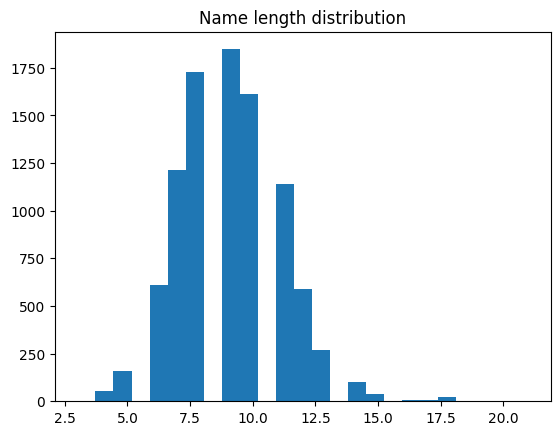

In [5]:
plt.title('Name length distribution')
plt.hist(list(map(len, names)), bins=25);

# Препроцессинг

In [6]:
#all unique characters go here
tokens = list(set(''.join(names)))

num_tokens = len(tokens)
print ('num_tokens = ', num_tokens)

num_tokens =  52


### Символы -> id

Создадим словарь < символ > -> < id >

In [7]:
token_to_id = {token: idx for idx, token in enumerate(tokens)}

In [8]:
assert len(tokens) == len(token_to_id), "dictionaries must have same size"

for i in range(num_tokens):
    assert token_to_id[tokens[i]] == i, "token identifier must be it's position in tokens list"

print("Seems alright!")

Seems alright!


In [9]:
def to_matrix(data, token_to_id, max_len=None, dtype='int32', batch_first = True):
    """Casts a list of names into rnn-digestable matrix"""

    max_len = max_len or max(map(len, data))
    data_ix = np.zeros([len(data), max_len], dtype) + token_to_id[' ']

    for i in range(len(data)):
        line_ix = [token_to_id[c] for c in data[i]]
        data_ix[i, :len(line_ix)] = line_ix

    if not batch_first: # convert [batch, time] into [time, batch]
        data_ix = np.transpose(data_ix)

    return data_ix

In [10]:
#Example: cast 4 names to matrices, pad with zeros
print('\n'.join(names[::2000]))
print(to_matrix(names[::2000], token_to_id))

 Ababko
 Chihachev
 Isaikov
 Nakhamkin
 Ustenko
[[49  9 23 32 23 11  5 49 49 49]
 [49 31 24 25 24 32 41 24 36 51]
 [49 42  4 32 25 11  5 51 49 49]
 [49 15 32 11 24 32 38 11 25 13]
 [49 33  4 35 36 13 11  5 49 49]]


# Рекуррентные нейронные сети

<img src="https://github.com/sic-rus-ai/stepik-dl-nlp/blob/master/img/rnn.png?raw=1" width=480>

In [11]:
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

In [12]:
class CharRNNCell(nn.Module):
    """
    Implement the scheme above as torch module
    """
    def __init__(self, num_tokens=len(tokens), embedding_size=16, rnn_num_units=64):
        super(self.__class__,self).__init__()
        self.num_units = rnn_num_units

        self.embedding = nn.Embedding(num_tokens, embedding_size)
        self.rnn_update = nn.Linear(embedding_size + rnn_num_units, rnn_num_units)
        self.rnn_to_logits = nn.Linear(rnn_num_units, num_tokens)

    def forward(self, x, h_prev):
        """
        This method computes h_next(x, h_prev) and log P(x_next | h_next)
        We'll call it repeatedly to produce the whole sequence.

        :param x: batch of character ids, variable containing vector of int64
        :param h_prev: previous rnn hidden states, variable containing matrix [batch, rnn_num_units] of float32
        """
        # get vector embedding of x
        x_emb = self.embedding(x)

        # compute next hidden state using self.rnn_update
        x_and_h = torch.cat([x_emb, h_prev], dim=1) #YOUR CODE HERE
        h_next = self.rnn_update(x_and_h) #YOUR CODE HERE

        h_next = F.tanh(h_next)

        assert h_next.size() == h_prev.size()

        #compute logits for next character probs
        logits = self.rnn_to_logits(h_next)

        return h_next, F.log_softmax(logits, -1)

    def initial_state(self, batch_size):
        """ return rnn state before it processes first input (aka h0) """
        return Variable(torch.zeros(batch_size, self.num_units))

In [13]:
char_rnn = CharRNNCell()

### Тренировка сети, RNN loop

In [14]:
def rnn_loop(rnn, batch_index):
    """
    Computes log P(next_character) for all time-steps in names_ix
    :param names_ix: an int32 matrix of shape [batch, time], output of to_matrix(names)
    """
    batch_size, max_length = batch_index.size()
    hid_state = rnn.initial_state(batch_size)
    logprobs = []

    for x_t in batch_index.transpose(0,1):
        hid_state, logp_next = rnn(x_t, hid_state)
        logprobs.append(logp_next)

    return torch.stack(logprobs, dim=1)

### Тренировка сети

In [15]:
from IPython.display import clear_output
from random import sample

char_rnn = CharRNNCell()
opt = torch.optim.Adam(char_rnn.parameters())
history = []

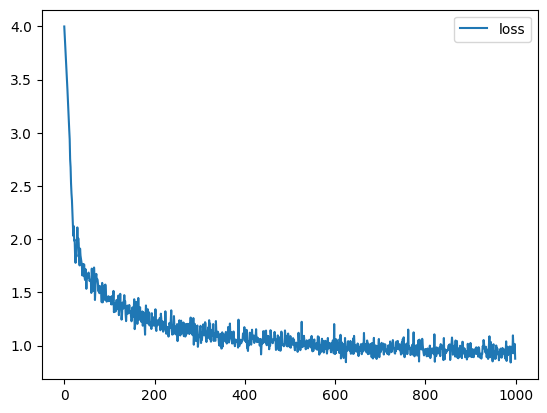

In [16]:
MAX_LENGTH = max(map(len, names))

for i in range(1000):
    batch_ix = to_matrix(sample(names, 32), token_to_id, max_len=MAX_LENGTH)
    batch_ix = torch.tensor(batch_ix, dtype=torch.int64)

    logp_seq = rnn_loop(char_rnn, batch_ix)

    # compute loss
    predictions_logp = logp_seq[:, :-1]
    actual_next_tokens = batch_ix[:, 1:]

    loss = -torch.mean(torch.gather(predictions_logp, dim=2, index=actual_next_tokens[:,:,None]))###YOUR CODE

    # train with backprop
    loss.backward()
    opt.step()
    opt.zero_grad()

    # visualizing training process
    history.append(loss.data.numpy())
    if (i + 1) % 100 == 0:
        clear_output(True)
        plt.plot(history,label='loss')
        plt.legend()
        plt.show()

assert np.mean(history[:10]) > np.mean(history[-10:]), "RNN didn't converge."

### RNN: генерация имен

In [17]:
def generate_sample(char_rnn, seed_phrase=' ', max_length=MAX_LENGTH, temperature=1.0):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''

    x_sequence = [token_to_id[token] for token in seed_phrase]
    x_sequence = torch.tensor([x_sequence], dtype=torch.int64)
    hid_state = char_rnn.initial_state(batch_size=1)

    #feed the seed phrase, if any
    for i in range(len(seed_phrase) - 1):
        hid_state, _ = char_rnn(x_sequence[:, i], hid_state)

    #start generating
    for _ in range(max_length - len(seed_phrase)):
        hid_state, logp_next = char_rnn(x_sequence[:, -1], hid_state)
        p_next = F.softmax(logp_next / temperature, dim=-1).data.numpy()[0]

        # sample next token and push it back into x_sequence
        next_ix = np.random.choice(len(tokens), p=p_next)
        next_ix = torch.tensor([[next_ix]], dtype=torch.int64)
        x_sequence = torch.cat([x_sequence, next_ix], dim=1)

    return ''.join([tokens[ix] for ix in x_sequence.data.numpy()[0]])

In [18]:
for _ in range(10):
    print(generate_sample(char_rnn))

 Talraev             
 Aastchyev           
 Tatukin             
 B'ronsiaamfov       
 Awdammev            
 Karelyanov          
 Barlekhentchov      
 Venzlinko           
 Hatehnin            
 Aevshv              


In [20]:
for _ in range(10):
    print(generate_sample(char_rnn, seed_phrase=' Ar', temperature = 0.2))

 Arorov              
 Arorov              
 Arolovin            
 Arorovin            
 Aralov              
 Aralev              
 Arinov              
 Ararov              
 Arovin              
 Arurovsky           


### Более простое решение

* `nn.RNNCell(emb_size, rnn_num_units)` - шаг RNN. Алгоритм: concat-linear-tanh
* `nn.RNN(emb_size, rnn_num_units` - весь rnn_loop.

Кроме того, в PyTorch есть `nn.LSTMCell`, `nn.LSTM`, `nn.GRUCell`, `nn.GRU`, etc. etc.

Перепишем наш пример с генерацией имен с помощью средств PyTorch.

In [21]:
class CharRNNLoop(nn.Module):
    def __init__(self, num_tokens=num_tokens, emb_size=16, rnn_num_units=64):
        super(self.__class__, self).__init__()
        self.emb = nn.Embedding(num_tokens, emb_size)
        self.rnn = nn.RNN(emb_size, rnn_num_units, batch_first=True)
        self.hid_to_logits = nn.Linear(rnn_num_units, num_tokens)

    def forward(self, x):
        assert isinstance(x, Variable) and isinstance(x.data, torch.LongTensor)
        h_seq, _ = self.rnn(self.emb(x))
        next_logits = self.hid_to_logits(h_seq)
        next_logp = F.log_softmax(next_logits, dim=-1)
        return next_logp

model = CharRNNLoop()
opt = torch.optim.Adam(model.parameters())
history = []

In [22]:
# the model applies over the whole sequence
batch_ix = to_matrix(sample(names, 32), token_to_id, max_len=MAX_LENGTH)
batch_ix = Variable(torch.LongTensor(batch_ix))

logp_seq = model(batch_ix)

# compute loss
loss = F.nll_loss(logp_seq[:, 1:].contiguous().view(-1, num_tokens),
                  batch_ix[:, :-1].contiguous().view(-1))

loss.backward()

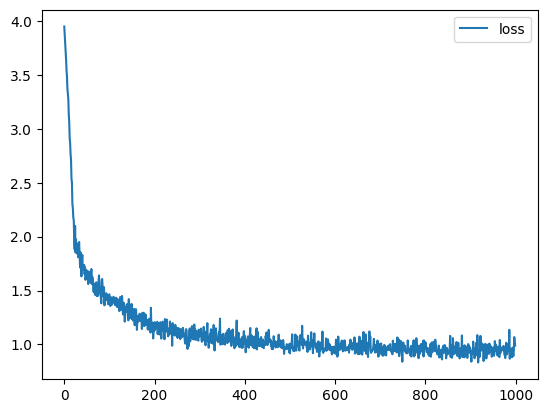

In [23]:
MAX_LENGTH = max(map(len, names))

for i in range(1000):
    batch_ix = to_matrix(sample(names, 32), token_to_id, max_len=MAX_LENGTH)
    batch_ix = torch.tensor(batch_ix, dtype=torch.int64)

    logp_seq = model(batch_ix)

    # compute loss
    predictions_logp = logp_seq[:, :-1]
    actual_next_tokens = batch_ix[:, 1:]

    loss = -torch.mean(torch.gather(predictions_logp, dim=2, index=actual_next_tokens[:,:,None]))

    # train with backprop
    loss.backward()
    opt.step()
    opt.zero_grad()

    history.append(loss.data.numpy())
    if (i + 1) % 100 == 0:
        clear_output(True)
        plt.plot(history, label='loss')
        plt.legend()
        plt.show()

assert np.mean(history[:25]) > np.mean(history[-25:]), "RNN didn't converge."

In [24]:
for _ in range(10):
    print(generate_sample(char_rnn))

 Frovmansko          
 Awiksky             
 Zachnyidcheev       
 Vamivon             
 Amuhev              
 Dchin               
 Mokhevig            
 Vorohintenkin       
 Modemovsky          
 Fusterkov           


### Домашнее задание: мотивационные лозунги

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from random import sample

In [25]:
# Если Вы запускаете ноутбук на colab или kaggle, добавьте в начало пути ./stepik-dl-nlp
with open('./stepik-dl-nlp/datasets/author_quotes.txt') as input_file:
    quotes = input_file.read()[:-1].split('\n')
    quotes = [' ' + line for line in quotes]

In [26]:
quotes[:5]

[' If you live to be a hundred, I want to live to be a hundred minus one day so I never have to live without you.',
 " Promise me you'll always remember: You're braver than you believe, and stronger than you seem, and smarter than you think.",
 ' Did you ever stop to think, and forget to start again?',
 ' Organizing is what you do before you do something, so that when you do it, it is not all mixed up.',
 ' Weeds are flowers too, once you get to know them.']

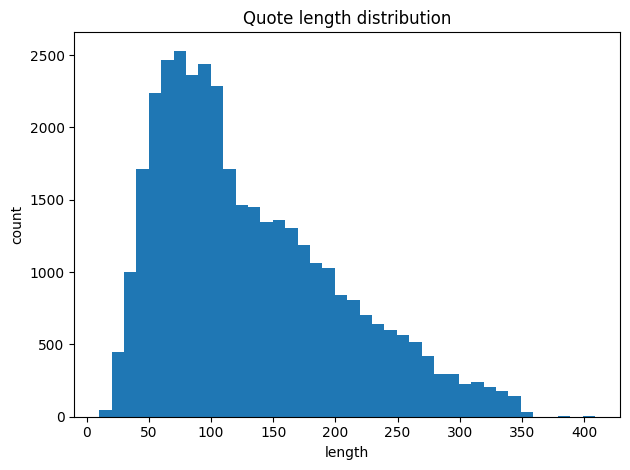

In [29]:
plt.title('Quote length distribution')
plt.hist(list(map(len, quotes)), bins=40)
plt.xlabel('length')
plt.ylabel('count')
plt.tight_layout()
plt.show()

In [27]:
tokens = list(set(''.join(quotes)))
token_to_id = {token: idx for idx, token in enumerate(tokens)}
num_tokens = len(tokens)

In [30]:
assert len(tokens) == len(token_to_id)
for i in range(num_tokens):
    assert token_to_id[tokens[i]] == i
print("Токены в порядке!")


def to_matrix(data, token_to_id, max_len=None, dtype='int32', batch_first=True):
    max_len = max_len or max(map(len, data))
    data_ix = np.zeros([len(data), max_len], dtype) + token_to_id[' ']
    for i in range(len(data)):
        line_ix = [token_to_id[c] for c in data[i]]
        data_ix[i, :len(line_ix)] = line_ix
    if not batch_first:
        data_ix = np.transpose(data_ix)
    return data_ix

Токены в порядке!


In [31]:
class CharRNNLoop(nn.Module):
    def __init__(self, num_tokens=num_tokens, emb_size=16, rnn_num_units=128):
        super(self.__class__, self).__init__()
        self.emb = nn.Embedding(num_tokens, emb_size)
        self.rnn = nn.RNN(emb_size, rnn_num_units, batch_first=True)
        self.hid_to_logits = nn.Linear(rnn_num_units, num_tokens)

    def forward(self, x):
        assert isinstance(x, torch.Tensor) and x.dtype == torch.int64
        h_seq, _ = self.rnn(self.emb(x))
        next_logits = self.hid_to_logits(h_seq)
        next_logp = F.log_softmax(next_logits, dim=-1)
        return next_logp

In [32]:
MAX_LENGTH = max(map(len, quotes))

def generate_sample(model, tokens, token_to_id,
                    seed_phrase=' ', max_length=200, temperature=1.0):
    model.eval()
    with torch.no_grad():
        x_sequence = [token_to_id[token] for token in seed_phrase]
        x_sequence = torch.tensor([x_sequence], dtype=torch.int64)

        h = None
        for i in range(len(seed_phrase) - 1):
            emb = model.emb(x_sequence[:, i:i+1])
            _, h = model.rnn(emb, h)

        for _ in range(max_length - len(seed_phrase)):
            emb = model.emb(x_sequence[:, -1:])
            rnn_out, h = model.rnn(emb, h)
            logits = model.hid_to_logits(rnn_out[:, -1, :])
            p_next = F.softmax(logits / temperature, dim=-1).numpy()[0]

            next_ix = np.random.choice(len(tokens), p=p_next)
            next_ix = torch.tensor([[next_ix]], dtype=torch.int64)
            x_sequence = torch.cat([x_sequence, next_ix], dim=1)

            if tokens[next_ix.item()] == '\n':
                break

    return ''.join([tokens[ix] for ix in x_sequence[0].numpy()])

step  100 | loss = 1.5052
step  200 | loss = 0.9795
step  300 | loss = 0.9026
step  400 | loss = 0.8369
step  500 | loss = 0.7951
step  600 | loss = 0.7552
step  700 | loss = 0.7396
step  800 | loss = 0.7185
step  900 | loss = 0.7008
step 1000 | loss = 0.6743

Обучение завершено!


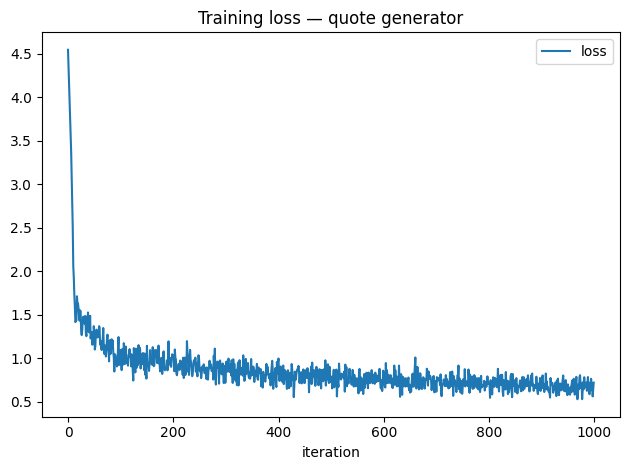

In [33]:
model = CharRNNLoop()
opt = torch.optim.Adam(model.parameters())
history = []

for i in range(1000):
    model.train()
    batch_ix = to_matrix(sample(quotes, 32), token_to_id, max_len=MAX_LENGTH)
    batch_ix = torch.tensor(batch_ix, dtype=torch.int64)

    logp_seq = model(batch_ix)

    predictions_logp = logp_seq[:, :-1]
    actual_next_tokens = batch_ix[:, 1:]

    loss = -torch.mean(
        torch.gather(predictions_logp, dim=2, index=actual_next_tokens[:, :, None])
    )

    loss.backward()
    opt.step()
    opt.zero_grad()

    history.append(loss.item())

    if (i + 1) % 100 == 0:
        print(f"step {i+1:4d} | loss = {np.mean(history[-100:]):.4f}")

assert np.mean(history[:25]) > np.mean(history[-25:]), "RNN не сошлась."
print("\nОбучение завершено!")

plt.figure()
plt.plot(history, label='loss')
plt.title('Training loss — quote generator')
plt.xlabel('iteration')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
print("\nСлучайная генерация (temperature=1.0)")
for _ in range(10):
    print(generate_sample(model, tokens, token_to_id))

print("\nГенерация с подсказкой 'The best' (temperature=0.5)")
for _ in range(5):
    print(generate_sample(model, tokens, token_to_id,
                          seed_phrase=' The best', temperature=0.5))

print("\nБолее хаотичная генерация (temperature=1.5)")
for _ in range(5):
    print(generate_sample(model, tokens, token_to_id, temperature=1.5))


Случайная генерация (temperature=1.0)
 I thind.                                                                                                                                                                                               
 I'bore tof aypertise wood, theos and foow- sritus the chors. I dorr shveaticast reve wore sectty, s'mertent hen't than Indere thenut to is the serariesod joso incorn ard the mak spvac worgy incoralal
 G'ko goous Istron asvougwief ah sual and jillt the erartering to ne tums iuse ho costhabd reer, was is isiold,  noth ofaplity dume to to the porecr the dor by newper. '                               
 I vuside hove ast of moinks it of rich ave ne mowine pround they. ghe fewlas antovan,  sey of it seplyarf dore, it dowly becuve rere optousay acl youn ppritire colmet in let peinger hinbn't the; bies
 AthBy latt a bele, hev is whay and belous, due orer the sugus!                                                                                              

### Что еще можно генерировать?
С помощью кода из этого семинара можно генерировать не только имена, но и:

* Повести/романы/поэзию/песни любимого автора
* Новостные заголовки
* Программный код
* Молекулы в формате [smiles](https://en.wikipedia.org/wiki/Simplified_molecular-input_line-entry_system)
* Музыку
* Названия мебели из ИКЕА
* Мотивационные лозунги
* etc.

__Удачи!__